In [19]:
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
import random
import json

import constants
from model_utils import *

from ast import literal_eval
from pathlib import Path

import matplotlib.cm as cm

from matplotlib.colors import LinearSegmentedColormap

import numpy as np

In [20]:
#plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'test'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

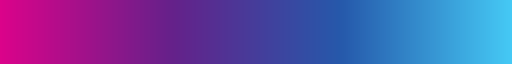

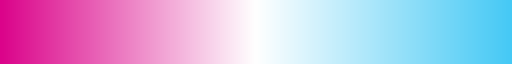

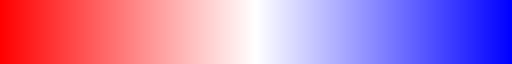

In [21]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], '#ffffff', finomnia_palette[-1]])
display(finomnia_cmap)
red_white_blue = LinearSegmentedColormap.from_list("red_blue", ["#ff0000", '#ffffff', "#0000ff"])
display(red_white_blue)


In [22]:
greens = sns.color_palette('Greens', 10)
blues = sns.color_palette('Blues', 10)
oranges = sns.color_palette('Oranges', 10)
reds = sns.color_palette('Reds', 10)
purples = sns.color_palette('Purples', 10)
greys = sns.color_palette('Greys', 10)

# Total performance

In [23]:
scores = pd.read_csv(base_dir / 'data' / 'metrics' / 'scores.csv')
scores.rename(
    columns={
        constants.OPENAI_GPT_4_1_NANO: 'GPT 4.1 Nano',
        f'{constants.OPENAI_GPT_4_1_NANO}_few-shots': 'GPT 4.1 Nano few-shots',
        f'{constants.OPENAI_GPT_4_1_NANO}_MMR': 'GPT 4.1 Nano few-shots MMR',
        constants.TUNED_GPT_4_1_NANO: 'GPT 4.1 Nano FT',
        constants.TUNED_GPT_4_1_NANO_OVERSAMPLE: 'GPT 4.1 Nano FT OS',
        constants.OPENAI_GPT_4_1_MINI: 'GPT 4.1 Mini',
        constants.OPENAI_GPT_4_1: 'GPT 4.1',
        #constants.TUNED_GPT_4_1_OVERSAMPLING: 'gpt_4_1_tuned_oversampling',
        #f'few_shots_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_few_shots',
        #f'MMR_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_MMR',
        constants.OPENAI_GPT_5_4: 'GPT 5.4 reasoning',
        constants.MISTRAL_LARGE_3: 'Mistral Large 3',
        constants.CLAUDE_OPUS_4_6: 'Opus 4.6',
        #f'few_shots_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_few_shots',
        #f'MMR_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_MMR'
    },
    inplace=True
)

train_scores = scores[scores.split=='train']
validation_scores = scores[scores.split=='validation']
test_scores = scores[scores.split=='test']

if SPLIT == 'val-test':
    scores = pd.concat([validation_scores, test_scores], ignore_index=True)
elif SPLIT == 'test':
    scores = test_scores
    
scores.set_index('id', inplace=True)

print(len(scores))

65


In [24]:
scores.head()

,split,Opus 4.6,GPT 4.1 Nano FT,GPT 4.1 Nano FT OS,GPT 4.1,GPT 4.1 Mini,GPT 4.1 Nano,GPT 4.1 Nano few-shots MMR,GPT 4.1 Nano few-shots,GPT 5.4 reasoning,Mistral Large 3
id,,,,,,,,,,,
46,test,0.736041,0.746193,0.811168,0.733503,0.733503,0.708122,0.682741,0.682741,0.758883,0.786802
47,test,1.000000,0.949239,0.949239,1.000000,1.000000,0.746193,0.796954,0.695431,1.000000,1.000000
53,test,0.685279,0.847716,0.888325,0.746193,0.743655,0.558376,0.532995,0.532995,0.898477,0.746193
54,test,0.708122,0.730118,0.583756,0.644670,0.746193,0.659898,0.659898,0.685279,0.695431,0.661591
56,test,0.644670,0.898477,0.847716,0.847716,0.695431,0.634518,0.634518,0.583756,0.847716,0.695431


In [25]:
compared_models = [
    'GPT 4.1 Nano',
    'GPT 4.1 Nano few-shots',
    'GPT 4.1 Nano few-shots MMR',
    'GPT 4.1 Nano FT',
    'GPT 4.1 Nano FT OS',
    #'GPT 4.1 Mini',
    #'GPT 4.1',
    #'GPT 5.4 reasoning',
    #'Mistral Large 3',
    #'Opus 4.6'
]
scores = scores[compared_models]

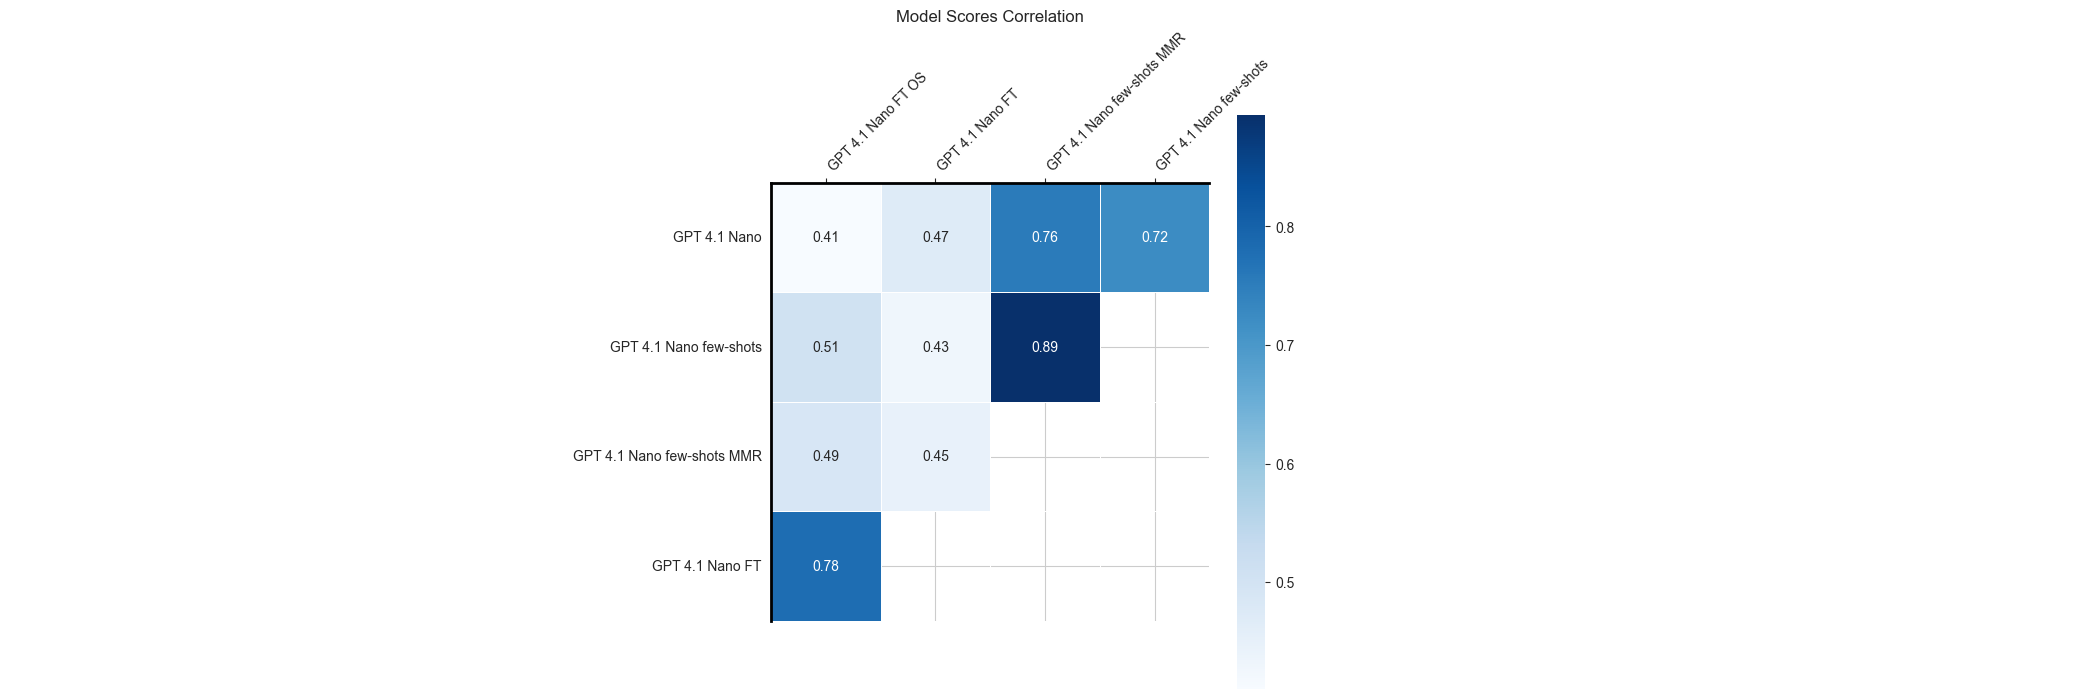

In [26]:
corr = scores.corr()
corr = corr[corr.columns[::-1]]
mask = np.tril(np.ones_like(corr, dtype=bool), k=0)
mask = mask[:, ::-1]

corr = corr.iloc[:-1, :-1]
mask = mask[:-1, :-1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)
    
ax = axes[1]
sns.heatmap(corr, mask=mask, cmap='Blues', annot=True,
                 fmt=".2f", square=True, linewidths=0.5, ax=ax)
                 #vmin=-1, vmax=1, center=0, ax=ax)
ax.set_facecolor("white")
ax.set_title("Model Scores Correlation")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')

plt.tight_layout()
plt.show()

In [27]:
corr

,GPT 4.1 Nano FT OS,GPT 4.1 Nano FT,GPT 4.1 Nano few-shots MMR,GPT 4.1 Nano few-shots
GPT 4.1 Nano,0.409944,0.470820,0.755647,0.723813
GPT 4.1 Nano few-shots,0.505915,0.429930,0.894120,1.000000
GPT 4.1 Nano few-shots MMR,0.489360,0.446294,1.000000,0.894120
GPT 4.1 Nano FT,0.780391,1.000000,0.446294,0.429930


In [28]:
couples = []
for i in range(len(corr)):
    for j in range(len(corr) - i):
        couples.append((i, j, corr.index[i], corr.columns[j]))

In [29]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [30]:
couples

[(0, 0, 'GPT 4.1 Nano', 'GPT 4.1 Nano FT OS'),
 (0, 1, 'GPT 4.1 Nano', 'GPT 4.1 Nano FT'),
 (0, 2, 'GPT 4.1 Nano', 'GPT 4.1 Nano few-shots MMR'),
 (0, 3, 'GPT 4.1 Nano', 'GPT 4.1 Nano few-shots'),
 (1, 0, 'GPT 4.1 Nano few-shots', 'GPT 4.1 Nano FT OS'),
 (1, 1, 'GPT 4.1 Nano few-shots', 'GPT 4.1 Nano FT'),
 (1, 2, 'GPT 4.1 Nano few-shots', 'GPT 4.1 Nano few-shots MMR'),
 (2, 0, 'GPT 4.1 Nano few-shots MMR', 'GPT 4.1 Nano FT OS'),
 (2, 1, 'GPT 4.1 Nano few-shots MMR', 'GPT 4.1 Nano FT'),
 (3, 0, 'GPT 4.1 Nano FT', 'GPT 4.1 Nano FT OS')]

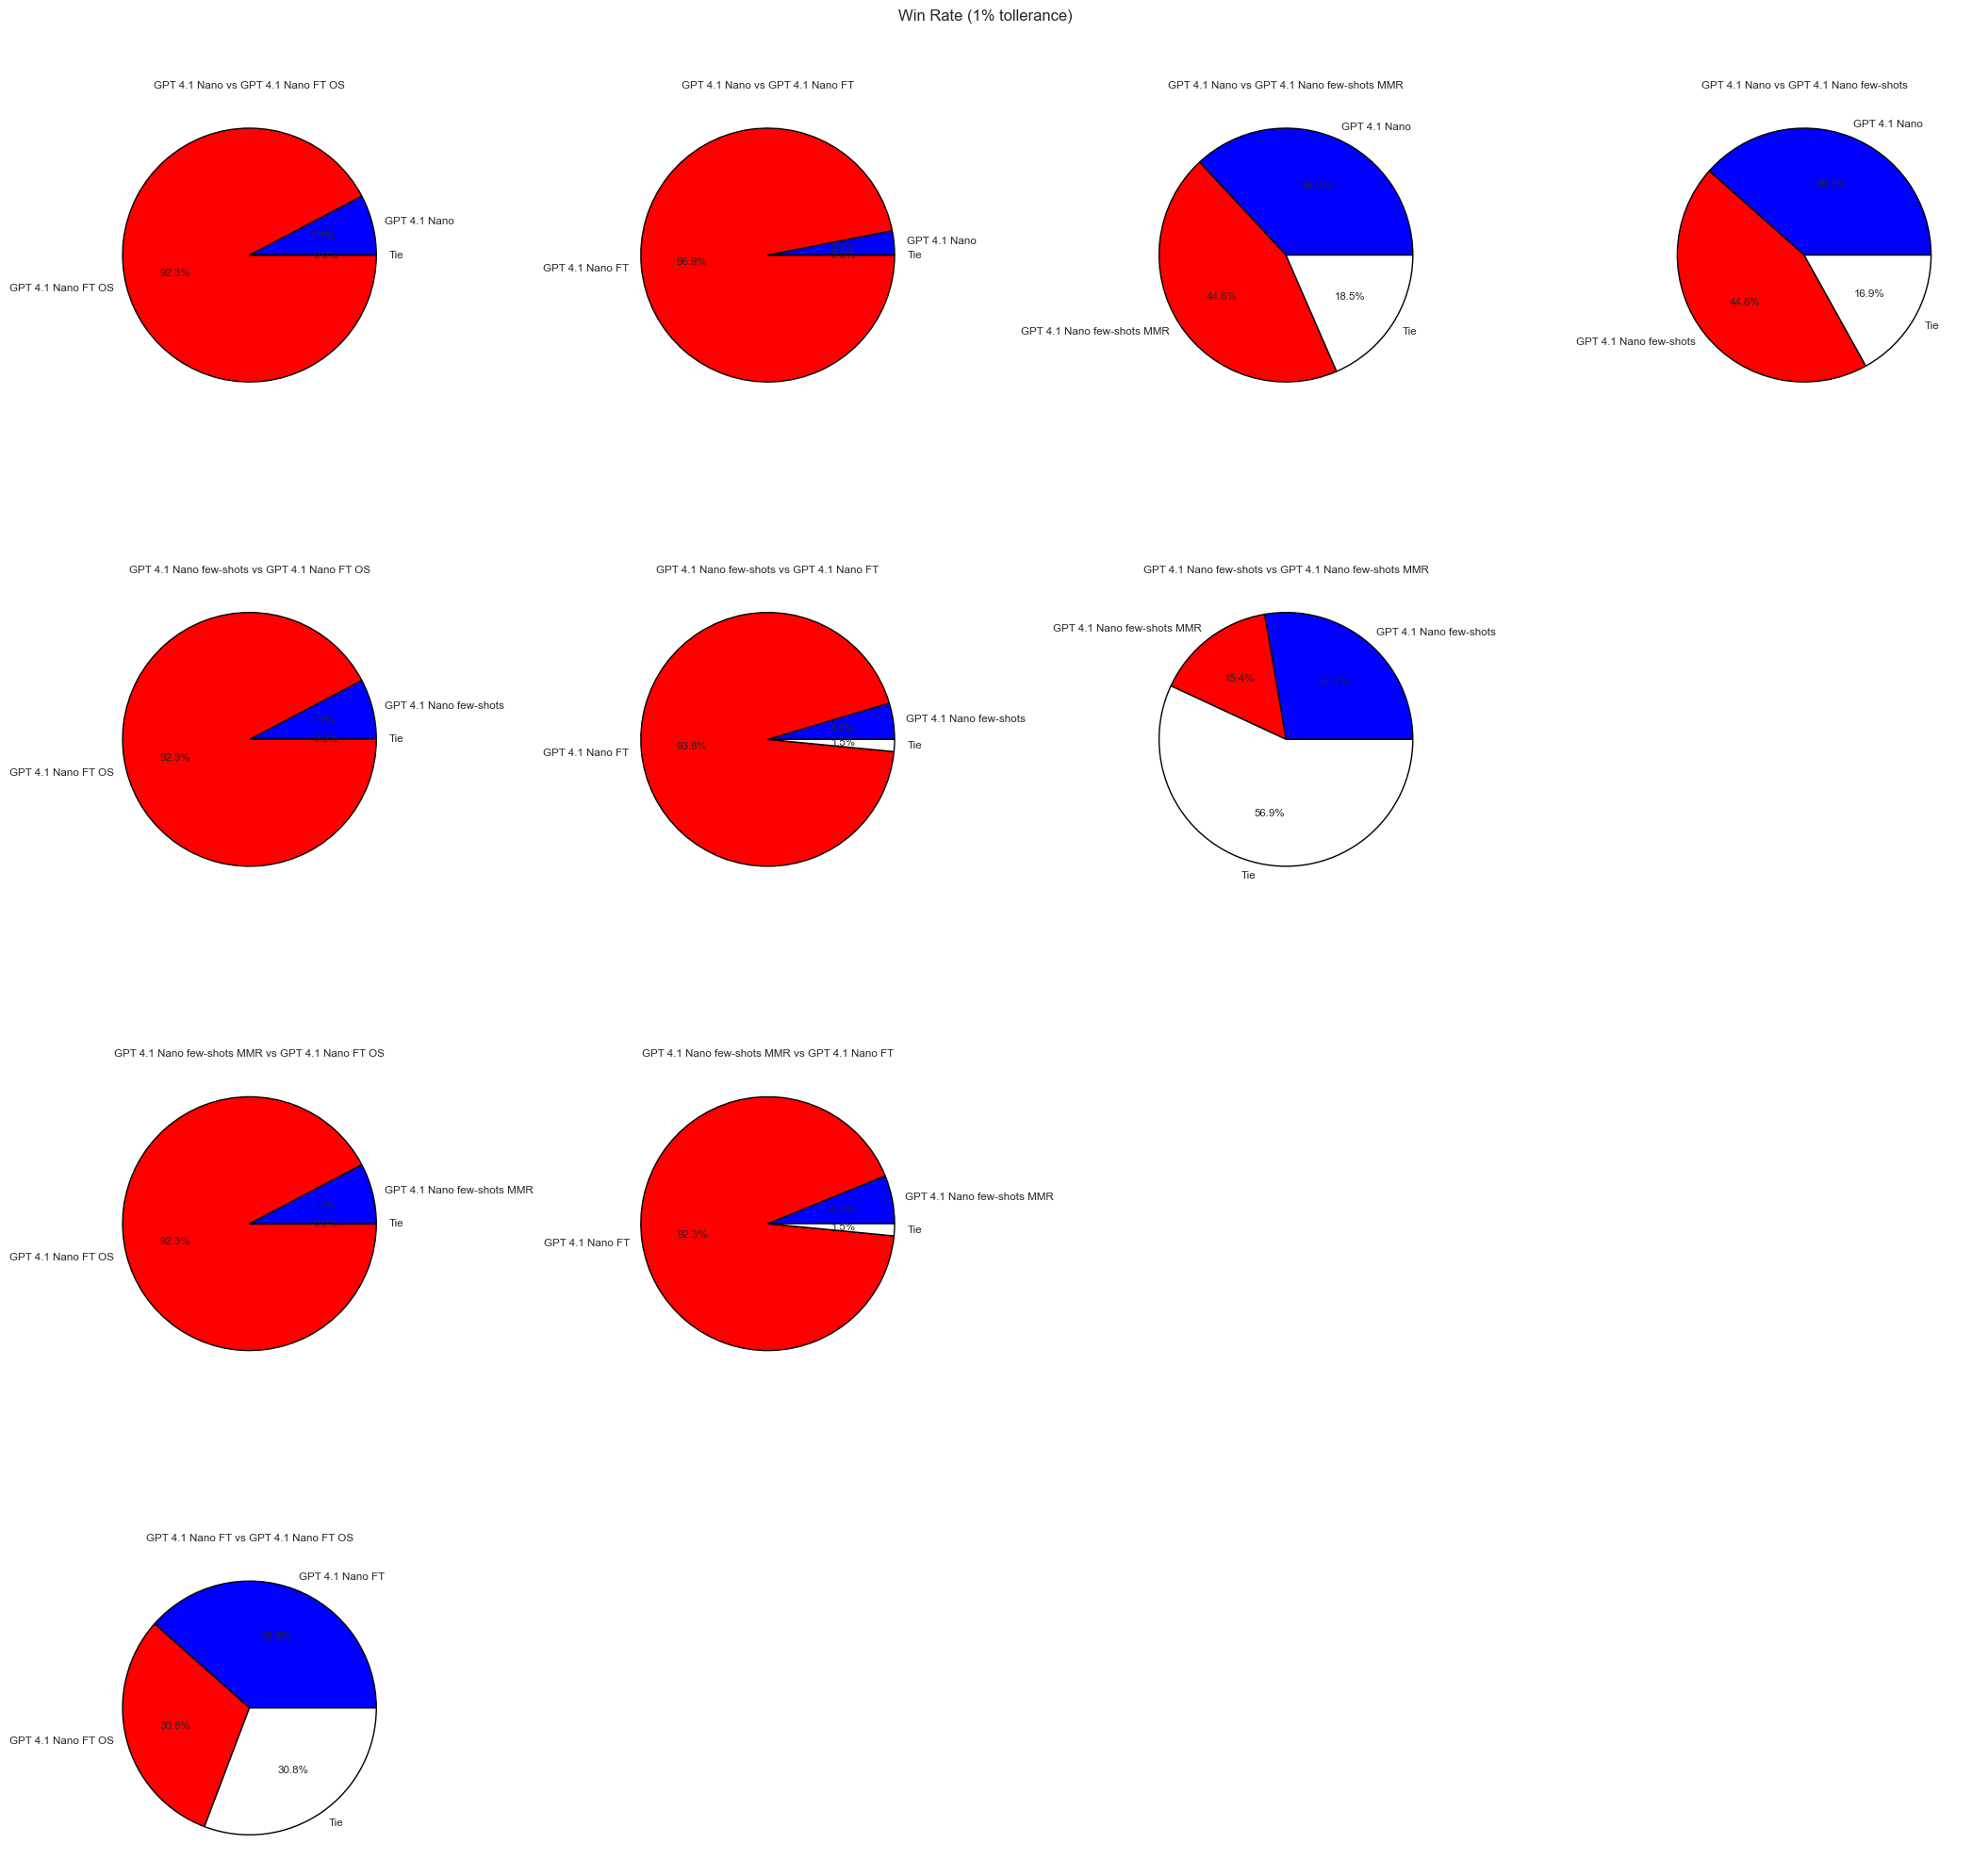

In [31]:
with plt.style.context('tableau-colorblind10'):
    fig, axes = plt.subplots(len(corr), len(corr), figsize=(21, 21))
    tol = 0.01
    fig.suptitle(f'Win Rate ({round(100*tol)}% tollerance) ')
    for c in couples:
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        m1_name = c[2]
        m2_name = c[3]
        m1 = scores[m1_name]
        m2 = scores[m2_name]
        
        counts = {
            f'{m1_name}': (m1 > m2 + tol).sum(),
            f'{m2_name}': (m2 > m1 + tol).sum(),
            f'Tie': ((m1 - m2).abs() <= tol).sum()
        }
            
        ax.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=["#0000ff", '#ff0000', "#ffffff"],
            wedgeprops={'edgecolor': 'black', 'linewidth': 1}, textprops={'fontsize': 'small'})
        ax.set_title(f'{m1_name} vs {m2_name}', fontsize='small')

    if isinstance(axes, np.ndarray):
        for i in range(1, len(axes)):
            for j in range(len(axes)-i, len(axes)):
                axes[i, j].set_visible(False) 
    plt.tight_layout()
    plt.show()

In [32]:
scores.min(axis=None)

np.float64(0.4991539763113367)

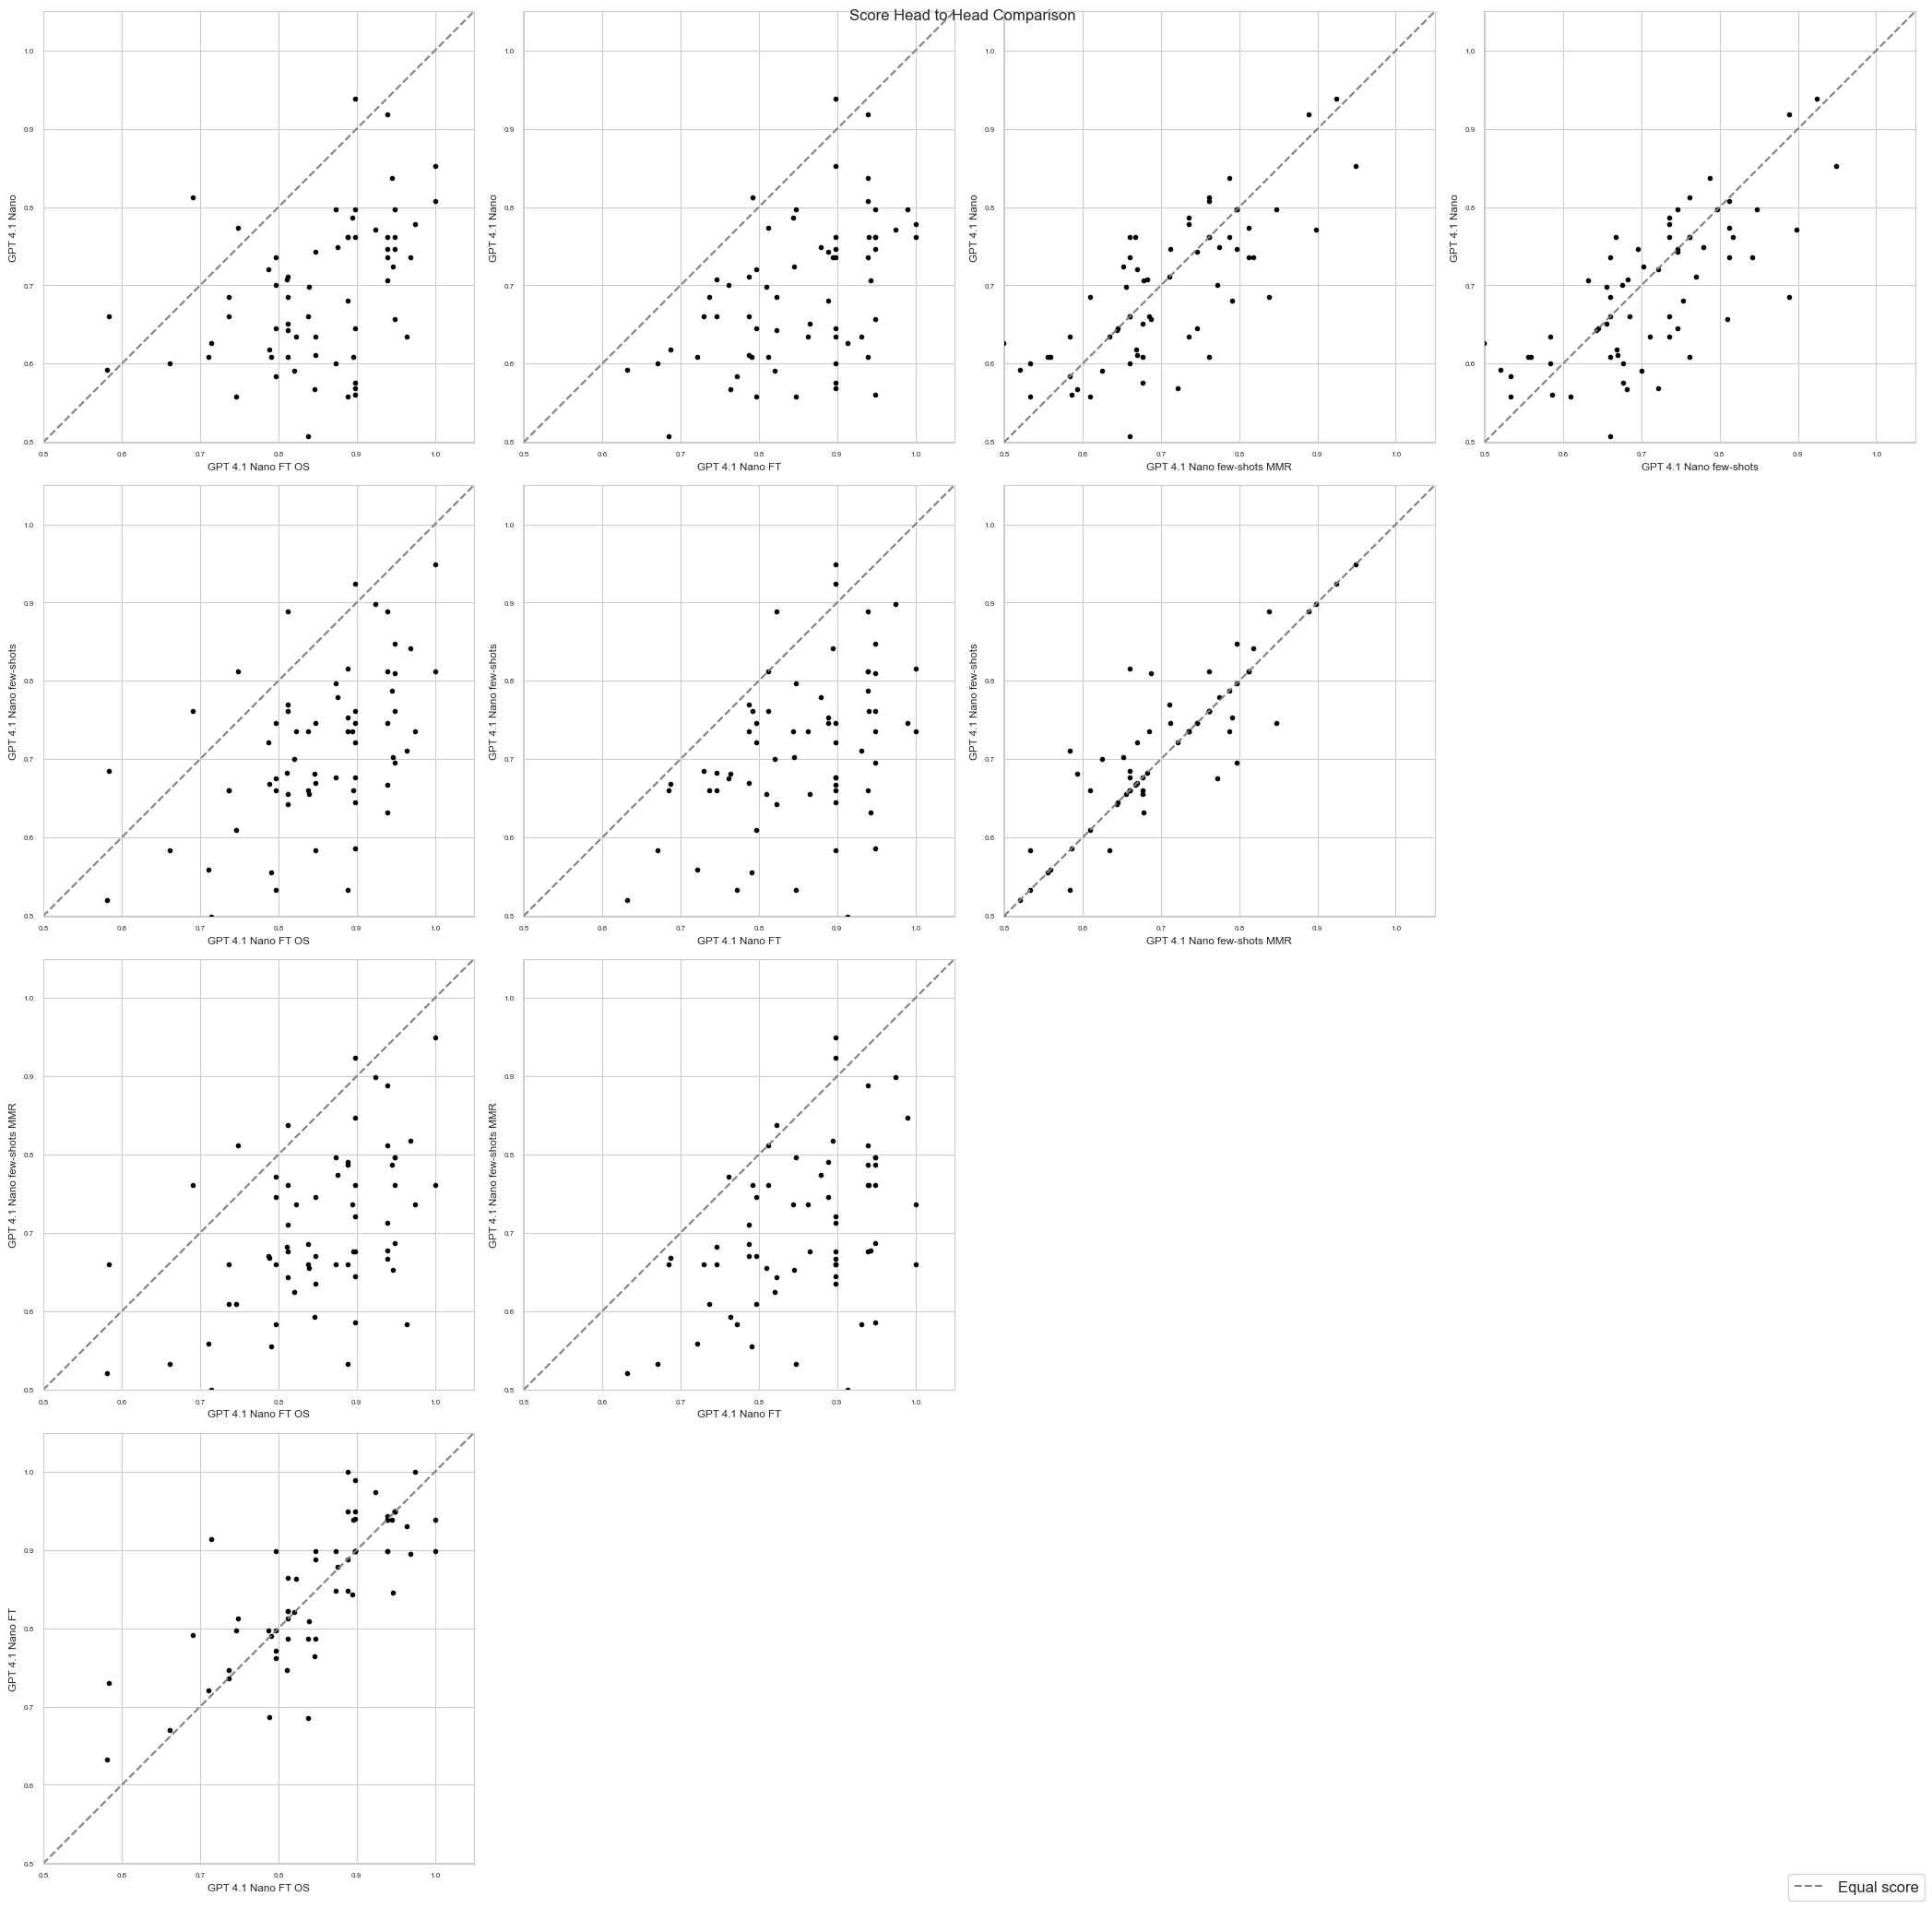

In [33]:
with plt.style.context('tableau-colorblind10'):

    fig, axes = plt.subplots(len(corr), len(corr), figsize=(21, 21))
    lo = scores.min(axis=None)
    for c in couples:
        
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        y = scores[c[2]]
        x = scores[c[3]]

        ax.scatter(x, y, marker='.', color='black')

        # dashed diagonal line
        #lo = min(x.min(), y.min())
        ax.axline((lo, lo), slope=1, ls='--', color='grey', label=f'Equal score')
        #ax.axline((0, 0), slope=1, ls='--', color='grey', label=f'Equal score')
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.set_ylabel(c[2], fontsize='small')
        ax.set_xlabel(c[3], fontsize='small')
        ax.tick_params(axis='both', labelsize='xx-small')
        ax.set_xlim((lo, 1.05))
        ax.set_ylim((lo, 1.05))
    if isinstance(axes, np.ndarray):
        for ax in axes.flat:
            if not ax.collections:
                ax.set_visible(False)
    #fig.legend()
    # Grab handle/label from any one subplot to avoid duplicates
    handles, labels = axes.flat[0].get_legend_handles_labels() if isinstance(axes, np.ndarray) else axes.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', fontsize='large')
    fig.suptitle(f'Score Head to Head Comparison')
    plt.tight_layout()
    plt.show()

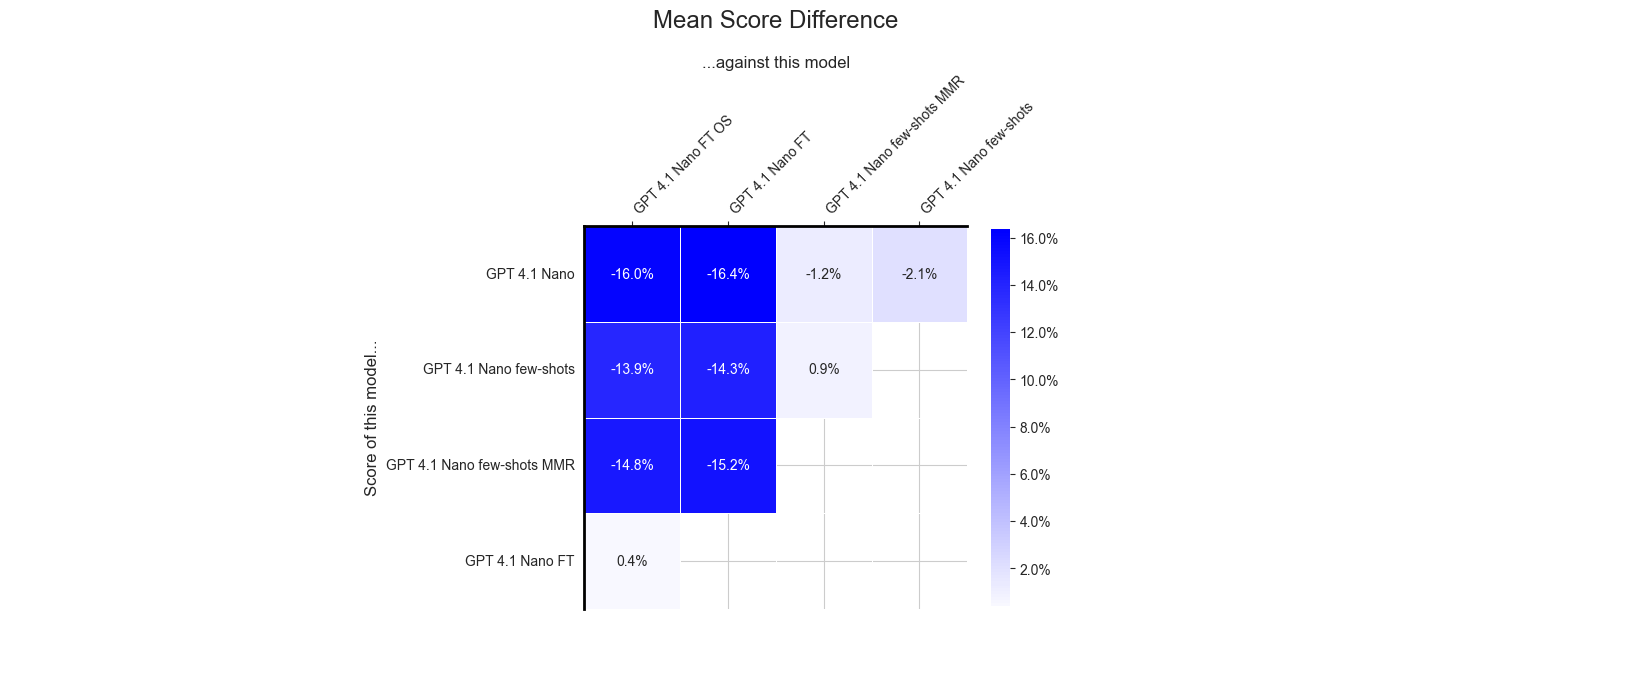

In [34]:
models = scores.columns.tolist()
n = len(models)

diff = pd.DataFrame(index=models, columns=models, dtype=float)

for i in models:
    for j in models:
        diff.loc[i, j] = (scores[i] - scores[j]).mean()


diff = diff[diff.columns[::-1]]
mask = np.tril(np.ones_like(diff, dtype=bool), k=0)
mask = mask[:, ::-1]

diff = diff.iloc[:-1, :-1]
mask = mask[:-1, :-1]


diff_pct = diff * 100

annot_labels = diff_pct.map(lambda x: f"{x:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
ax = axes[1]
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)

sns.heatmap(diff_pct.abs(), annot=annot_labels, fmt="", cmap=red_white_blue,
                 square=True, linewidths=0.5, mask=mask, ax=ax, center=0, cbar_kws={"shrink": 0.7})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")

ax.set_title("Mean Score Difference", pad=20, fontsize='xx-large')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_ylabel('Score of this model...', fontsize='large')
ax.set_xlabel('...against this model', fontsize='large')
ax.set_facecolor("white")

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')


#plt.tight_layout()
plt.show()

C:\Users\lucat\AppData\Local\Temp\ipykernel_20508\4062181511.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')


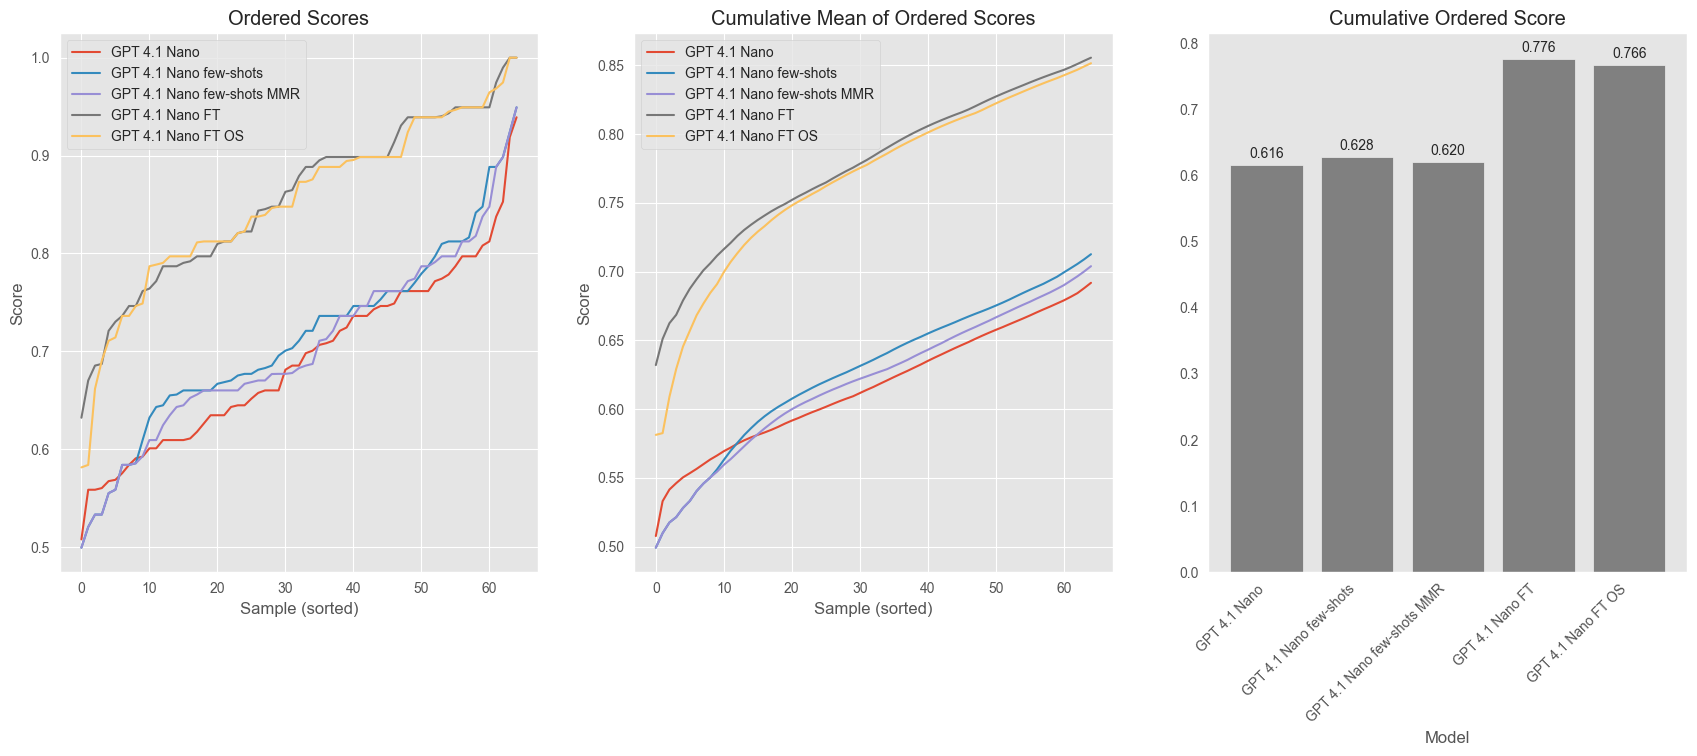

In [35]:
sorted_scores = scores.apply(lambda col: col.sort_values().reset_index(drop=True))
cumulative_mean = sorted_scores.expanding().mean()
cumulative_ordered_score = cumulative_mean.mean()

#with plt.style.context('tableau-colorblind10'):
with plt.style.context('ggplot'):
    x = np.arange(len(sorted_scores))
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))
    
    for m in sorted_scores.columns:
        ax1.plot(x, sorted_scores[m], label=m)
        ax2.plot(x, cumulative_mean[m], label=m)
    
    bars = ax3.bar(cumulative_ordered_score.index, cumulative_ordered_score.values, color='grey')
    ax3.bar_label(bars, fmt='%.3f', padding=3)
    
    ax1.legend()
    ax1.set_xlabel('Sample (sorted)')
    ax1.set_ylabel('Score')
    ax1.set_title('Ordered Scores')
    
    ax2.legend()
    ax2.set_xlabel('Sample (sorted)')
    ax2.set_ylabel('Score')
    ax2.set_title('Cumulative Mean of Ordered Scores')
    ax2.legend()
    
    ax3.set_xlabel('Model')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
    ax3.set_title('Cumulative Ordered Score')
    ax3.grid(False)


GPT 4.1 Nano                  0.616168
GPT 4.1 Nano few-shots        0.627681
GPT 4.1 Nano few-shots MMR    0.619902
GPT 4.1 Nano FT               0.776326
GPT 4.1 Nano FT OS            0.766305
dtype: float64


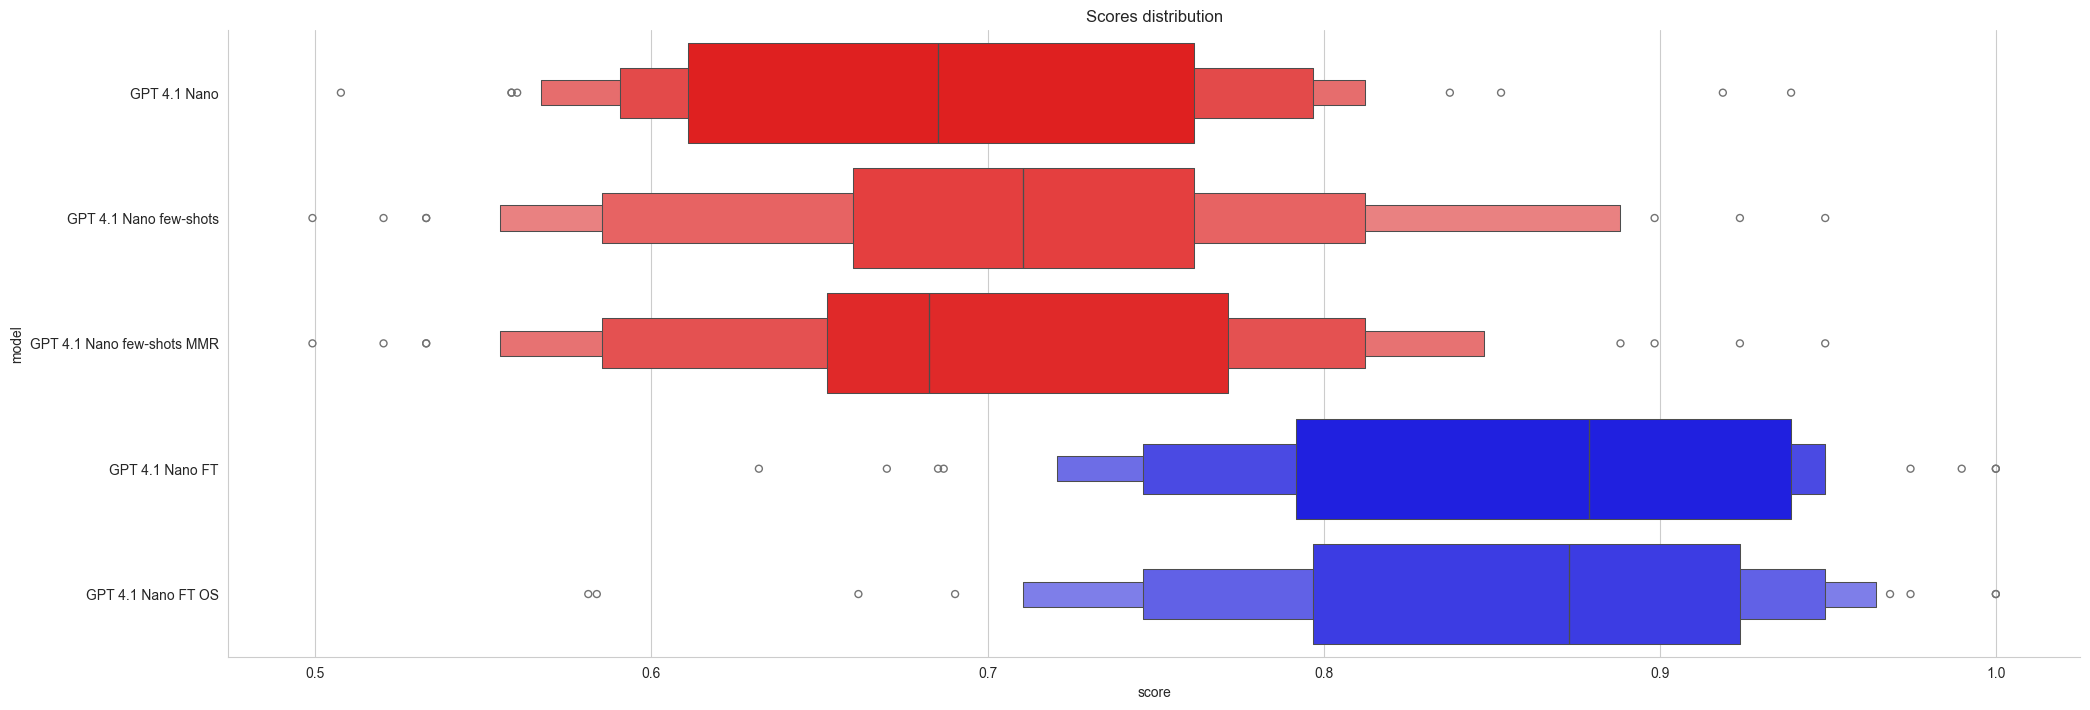

In [36]:
# Normalizziamo COS tra 0 e 1
norm_scores = (cumulative_ordered_score - cumulative_ordered_score.min()) / (cumulative_ordered_score.max() - cumulative_ordered_score.min())



print(cumulative_ordered_score)
palette_sharpe_scores = {model: red_white_blue(norm_scores[model]) for model in cumulative_ordered_score.index}

scores_melted = scores.melt(var_name='model', value_name='score')
sns.catplot(data=scores_melted, y="model", x="score", kind='boxen', height=7, aspect=21/7, palette=palette_sharpe_scores, hue='model')
plt.title("Scores distribution")
plt.show()